2. Data Preparation

This notebook will prepare the data for machine learning:
- download card images
- resize to 120x168 RGB (width x height)
- map the rarities to 5 classes
- handle class imbalance 
- one-hot encode labels
- save prepared data to disk

In [1]:
import sys
sys.path.insert(0, '..')

from data.dataset import Dataset
from data.rarity_classes import RARITY_CLASSES
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
print(os.getcwd())

/Users/markusgarmeister/Desktop/ML_PokeCard/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/markusgarmeister/Desktop/ML_PokeCard/notebooks


2.1 Load mapped Data

First we load the data with our mapped rarity. In the dataset are about ~300 cards, which have no rarity label. In the data exploration I inspected a few of them, in order to see if there is a certain pattern or kind of card. However from my investigation it looks like there are all kind of cards in there (energy, promo, common, ...). Therefore I decided to neglect theim, since it just a small part of the over 18,000 cards.

Total cards in dataset with rarity label: 17915

Class distribution:
mapped_rarity
Rare           5189
Common         4632
Uncommon       4407
Ultra Rare     2328
Secret Rare    1359
Name: count, dtype: int64


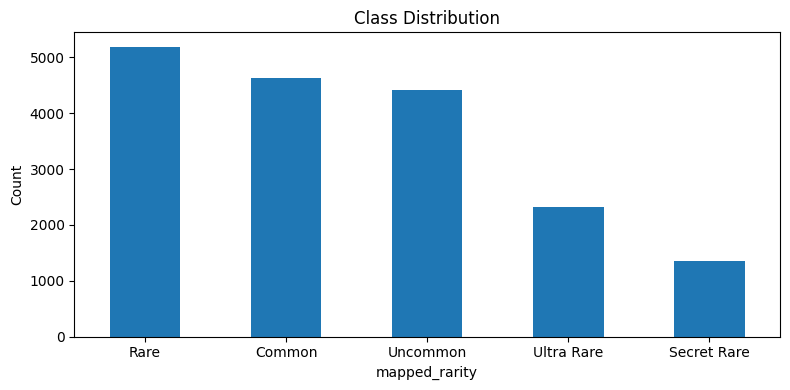

In [2]:
dataset = Dataset()
df = dataset.get_mapped_dataset()
df = df[df['mapped_rarity'].notna()]
print(f"Total cards in dataset with rarity label: {len(df)}")
print(f"\nClass distribution:")
print(df['mapped_rarity'].value_counts())

df['mapped_rarity'].value_counts().plot(kind='bar', figsize=(8, 4))           
plt.xticks(rotation=0)                                                        
plt.title('Class Distribution')                                               
plt.ylabel('Count')
plt.tight_layout()
plt.show()

2.2 Undersampling and Download Images

Even though we mapped the rarity labels, our classes are not balanced. Ultra rares are about the half of rares and Secret rares about a third of rares. Instead of duplicating the data of the less represented classes (oversample), I decided to undersample the classes to 500 images per class, because first of all the model should see each class the same amount, in order to prevent the model to be biased towards Common, Uncommon and Rare cards. The second reason for undersampling is to make the training process faster.

In [3]:
MAX_PER_CLASS = 500
balanced_df = df.groupby('mapped_rarity').apply(lambda x: x.sample(MAX_PER_CLASS))
x_images, y_labels, failed = dataset.download_images(balanced_df)
print(f"\nSuccessfully loaded: {len(x_images)} images")
print(f"Failed downloads: {failed}")
print(f"\nClass distribution after undersampling:")


https://images.pokemontcg.io/sm11/165.png


/var/folders/sk/rs8l7jb53ms_qdt354_4brmm0000gn/T/ipykernel_4581/2138852405.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('mapped_rarity').apply(lambda x: x.sample(MAX_PER_CLASS))


https://images.pokemontcg.io/swsh45/49.png
https://images.pokemontcg.io/ex6/102.png
https://images.pokemontcg.io/sm6/99.png
https://images.pokemontcg.io/ex8/54.png
https://images.pokemontcg.io/sm11/171.png
https://images.pokemontcg.io/dp7/62.png
https://images.pokemontcg.io/base6/109.png
https://images.pokemontcg.io/swsh9/24.png
https://images.pokemontcg.io/sv3pt5/16.png
https://images.pokemontcg.io/xy11/33.png
https://images.pokemontcg.io/sm12/47.png
https://images.pokemontcg.io/sm35/50.png
https://images.pokemontcg.io/ex1/76.png
https://images.pokemontcg.io/sv7/108.png
https://images.pokemontcg.io/ex10/75.png
https://images.pokemontcg.io/ex13/78.png
https://images.pokemontcg.io/dp6/123.png
https://images.pokemontcg.io/swsh3/14.png
https://images.pokemontcg.io/sv5/1.png
https://images.pokemontcg.io/base1/57.png
https://images.pokemontcg.io/ecard2/82.png
https://images.pokemontcg.io/gym2/80.png
https://images.pokemontcg.io/dp3/102.png
https://images.pokemontcg.io/swsh11/24.png
https://

2.3 Convert to NumPy Arrays

I'm converting the images to an numpy array and one-hot encode the 5 rarity class.
[1, 0, 0, 0, 0] -> Common
[0, 1, 0, 0, 0] -> Uncommon
[0, 0, 1, 0, 0] -> Rare
[0, 0, 0, 1, 0] -> Ultra Rare
[0, 0, 0, 0, 1] -> Secret Rare

In [17]:
print(x_images[0])
print(y_labels[0])
print(len(x_images))
print(len(y_labels))

# Convert images to numpy array
X = np.array(x_images)
print(X.shape)

# One-hot encode labels
label_to_idx = {label: idx for idx, label in enumerate(RARITY_CLASSES)}
y_indices = np.array([label_to_idx[label] for label in y_labels])
y = np.eye(len(RARITY_CLASSES))[y_indices]
print(f"y shape: {y.shape}")  # (N, 5)

print(f"\nLabel encoding:")
for label, idx in label_to_idx.items():
    print(f"  {idx}: {label}")
 

[[[ 96  84  37]
  [247 222  97]
  [255 226  99]
  ...
  [255 226  99]
  [247 222  97]
  [ 96  84  37]]

 [[251 222  98]
  [255 226 100]
  [255 225  99]
  ...
  [255 225  99]
  [255 226 100]
  [251 222  98]]

 [[255 226  99]
  [255 225  99]
  [255 225  99]
  ...
  [255 225  99]
  [255 225  99]
  [255 226  99]]

 ...

 [[255 226  99]
  [255 225  99]
  [255 225  99]
  ...
  [255 225  99]
  [255 225  99]
  [255 226  99]]

 [[251 222  98]
  [255 226 100]
  [255 225  99]
  ...
  [255 225  99]
  [255 226 100]
  [251 222  98]]

 [[ 96  84  37]
  [247 222  97]
  [255 226  99]
  ...
  [255 226  99]
  [247 222  97]
  [ 96  84  37]]]
Common
2500
2500
(2500, 168, 120, 3)
y shape: (2500, 5)

Label encoding:
  0: Common
  1: Uncommon
  2: Rare
  3: Ultra Rare
  4: Secret Rare


2.4 Storing Data 

I'm storing the data to disk. The images and the one hot encoded rarirty classs will be stored as numpy array under /data/dataclass/  

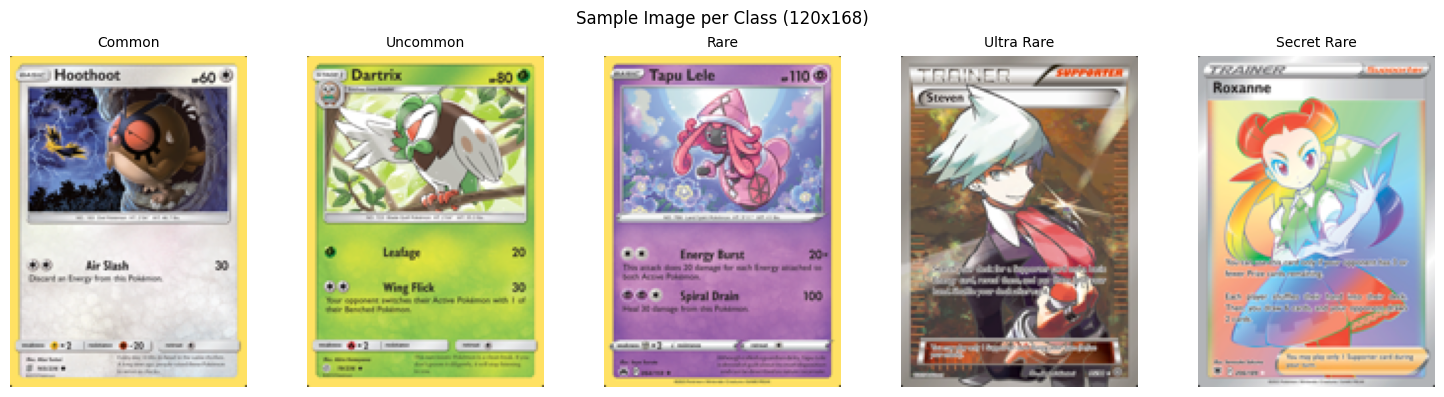

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, cls in enumerate(RARITY_CLASSES):
    idx = np.where(y_indices == i)[0][0]
    axes[i].imshow(X[idx])
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis('off')
plt.suptitle('Sample Image per Class (120x168)', fontsize=12)
plt.tight_layout()
plt.show()

#store prep data
dataset.store_prep_data(X, y)

Summary

- Downloaded 2500 card images ( 500 per class)
- Resized all images to 120x168 RGB
- One-hot encoded 5 rarity classes 
- Saved prepared data as .npy file in /data/dataset